<div dir="rtl">

# مختبر إثرائي — من تحويل فورييه إلى نظيره الكمومي بالبناء التدريجي

**QSilver39 · مادة إثرائية · يرافق الملف التفاعلي `qsilver-d3-ft-deep-ar.html`**

رحلة الملف التفاعلي نفسها بأداة القياس: إشارة، فلفّ، فعينات وتوائمها الخادعة، فضغط، فسعات، فبوابات — وفي القلب **المعادلة القابلة للفحص**: مصفوفة الدائرة الكمومية تساوي مصفوفة DFT تساويًا يثبته `assert` لا جملة إنشائية.

> **كل ادعاء عددي يرافقه سطر `assert` يتحقق منه في كل تشغيل.**

المتطلبات: `qiskit` و `qiskit-aer` و `numpy` و `matplotlib`. **اتفاقان:** (1) نصوص المخططات بالإنجليزية عمدًا — عرض العربية داخل matplotlib يتطلب تجهيز خطوط غير متوفر عادة عند المتدربين. (2) نعتمد اتفاق Qiskit: **الكيوبت 0 أدنى خانة** — دالة `qft` في دفتر D02 تسمي `qubits[0]` أعلى خانة؛ البوابات هي هي والتسمية معكوسة فقط.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

# Extra Lab — From the Fourier Transform to its Quantum Counterpart, step by step

**QSilver39 · enrichment material · companion to the interactive file `qsilver-d3-ft-deep-ar.html`**

The interactive file's journey, on the measuring instrument: a signal, winding, samples and their deceptive twins, compression, amplitudes, gates — and at the center **the checkable equation**: the quantum circuit's matrix equals the DFT matrix, proven by an `assert`, not by prose.

> **Every numerical claim is accompanied by an `assert` that checks it on every run.**

Requirements: `qiskit`, `qiskit-aer`, `numpy`, `matplotlib`. **Two conventions:** (1) plot text is deliberately English-only — Arabic in matplotlib needs font setup trainees usually lack. (2) We use Qiskit's ordering: **qubit 0 is the least-significant bit** — notebook D02's `qft` names `qubits[0]` most-significant; same gates, mirrored labels.

</div>

In [1]:
# ============================================================
# Imports, palette, constants
# [AR] الاستيرادات ولوحة ألوان الملفات التفاعلية والثوابت
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, sin, cos

TAU = 2 * pi
# palette shared with the interactive HTML files:
INK, WAVE, MIRROR, PIN, ANGLE = "#1C2340", "#17916C", "#C4551F", "#B87514", "#6C63D8"

rng = np.random.default_rng(7)          # seeded -> reproducible numbers every run
print("environment ready")

environment ready


<div dir="rtl">

---
## المحطة الأولى — الإشارة والمعادلة بوجهيها

نبني إشارة من نغمتين (الحاويتان 3 و 9 من 64) ونحسب تحويلها **بالصيغتين** من المحطة الأولى في الملف: صيغة أويلر \(X_k=\sum_n x_n e^{-2\pi i kn/N}\)، وصيغة المثلثات: مطابقة مع جيب التمام (الجزء الحقيقي) ومع الجيب (التخيلي). الادعاء: **الصيغتان عملية واحدة** — و`assert` يثبته مصفوفيًا.

### المهمة 1
قبل التشغيل: عند أي حاويتين تتوقع قمتي المقدار؟ ولماذا تظهر قمم عند 55 و 61 أيضًا؟

<details><summary>الحل | Solution</summary>

عند 3 و 9. وتظهر مرآتاهما 61 = 64−3 و 55 = 64−9 لأن الإشارة حقيقية فطيفها متناظر حول المنتصف.
At bins 3 and 9; their mirrors 61 = 64−3 and 55 = 64−9 appear because a real signal has a spectrum symmetric about the midpoint.
</details>

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 1 — The signal and both faces of the equation

We build a two-tone signal (bins 3 and 9 of 64) and compute its transform **in both forms** from the file's first station: the Euler form \(X_k=\sum_n x_n e^{-2\pi i kn/N}\), and the trigonometric form — correlation with cosine (real part) and with sine (imaginary part). The claim: **the two forms are one operation** — and an `assert` proves it matrix-wide.

### Task 1
Before running: at which two bins do you expect the magnitude peaks? Why do peaks also appear at 55 and 61?

</div>

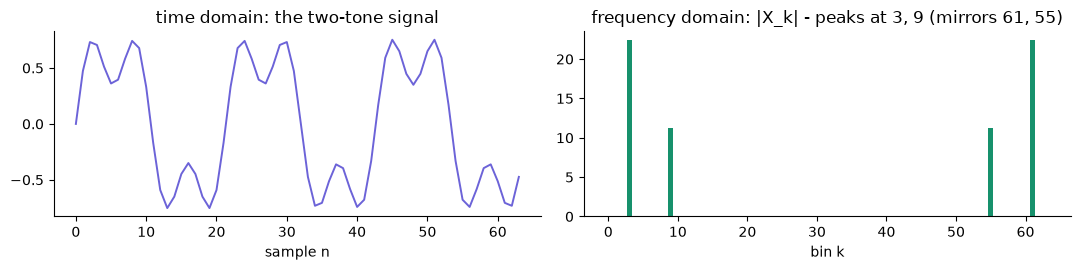

verified: Euler form == trig form, and peaks land exactly on the tone bins


In [2]:
# ============================================================
# Station 1: two-tone signal; Euler form vs trigonometric form of the DFT
# [AR] إشارة نغمتين وحساب التحويل بصيغة أويلر وصيغة المثلثات وإثبات تطابقهما
# ============================================================
Nsig = 64
t = np.arange(Nsig)
# the signal: 0.7 x tone at bin 3 + 0.35 x tone at bin 9 (same as the HTML demo):
x = 0.7 * np.sin(TAU * 3 * t / Nsig) + 0.35 * np.sin(TAU * 9 * t / Nsig)

def dft_euler(x):
    """X_k = sum_n x_n e^{-2 pi i k n / N}  - the Euler (complex-exponential) form.
    [AR] صيغة أويلر: الضرب في عامل اللف المركب ثم الجمع"""
    Nl = len(x); n_ = np.arange(Nl)
    # outer product k*n builds every winding angle at once (an N x N phase table):
    W = np.exp(-2j * pi * np.outer(n_, n_) / Nl)
    return W @ x

def dft_trig(x):
    """Real part = correlation with cos, imaginary = -correlation with sin.
    [AR] صيغة المثلثات: مطابقة مع جيب التمام ومع الجيب كلا على حدة"""
    Nl = len(x); n_ = np.arange(Nl)
    angles = TAU * np.outer(n_, n_) / Nl
    return (np.cos(angles) @ x) - 1j * (np.sin(angles) @ x)

X_e, X_t = dft_euler(x), dft_trig(x)

# CLAIM 1: Euler and trig forms are the SAME operation (e^{-i a} = cos a - i sin a):
assert np.allclose(X_e, X_t)
# CLAIM 2: magnitude peaks sit exactly at the tone bins 3 and 9 (first half):
mags = np.abs(X_e)
assert mags[3] > 20 and mags[9] > 10 and np.argsort(mags[:32])[-1] == 3 and np.argsort(mags[:32])[-2] == 9

fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
axes[0].plot(t, x, color=ANGLE, lw=1.4)
axes[0].set_title("time domain: the two-tone signal"); axes[0].set_xlabel("sample n")
axes[1].bar(range(Nsig), mags, color=WAVE, width=0.7)
axes[1].set_title("frequency domain: |X_k| - peaks at 3, 9 (mirrors 61, 55)")
axes[1].set_xlabel("bin k")
for ax in axes:
    for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("verified: Euler form == trig form, and peaks land exactly on the tone bins")

<div dir="rtl">

---
## المحطة الثانية — حيلة اللف رقميًا

مختبر الميكروفون يعيش في المتصفح؛ هنا ننفذ جوهره الحسابي: **لفّ الإشارة حول الدائرة بسرعة f ثم أخذ مركز الثقل** — وهو حرفيًا حدُّ المجموع \(\frac{1}{N}\sum_n x_n e^{-2\pi i f n/N}\). نرسم مسار اللف عند سرعتين: سرعة خاطئة (اللفائف تتلاشى) وسرعة نغمةٍ فعلية (تصطف ويكبر مركز الثقل):

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 2 — The winding trick, numerically

The microphone lab lives in the browser; here we run its computational core: **wind the signal around a circle at rate f and take the center of mass** — literally the sum \(\frac{1}{N}\sum_n x_n e^{-2\pi i f n/N}\). We draw the wound path at two rates: a wrong rate (the coils cancel) and an actual tone's rate (they align and the center of mass grows):

</div>

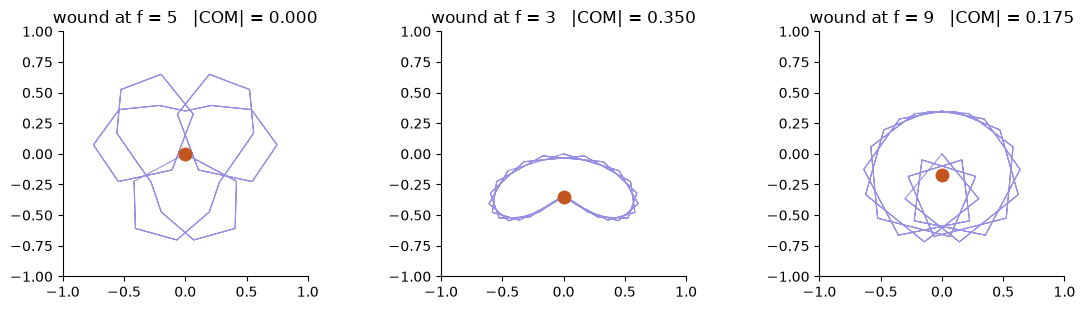

verified: winding center-of-mass peaks only at the true tone rates (3 and 9)


In [3]:
# ============================================================
# Station 2: wind the signal at rate f; center of mass |mean| peaks at true tones
# [AR] لف الإشارة بسرعة f: مركز الثقل يتضخم عند سرعات النغمات الحقيقية فقط
# ============================================================
def wound(x, f):
    """Complex path of the signal wound at rate f, and its center of mass.
    [AR] مسار الإشارة الملفوفة بسرعة f ومركز ثقله"""
    Nl = len(x)
    path = x * np.exp(-2j * pi * f * np.arange(Nl) / Nl)   # each sample rotated
    return path, path.mean()                               # center of mass = the FT value / N

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2))
for f, ax in zip((5.0, 3.0, 9.0), axes):
    path, com = wound(x, f)
    ax.plot(path.real, path.imag, color=ANGLE, lw=0.8, alpha=0.7)
    ax.plot(com.real, com.imag, "o", color=MIRROR, ms=9)          # the center of mass
    ax.set_title(f"wound at f = {f:g}   |COM| = {abs(com):.3f}")
    ax.set_aspect("equal"); ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

# CLAIM: the center of mass is large exactly at the tone rates and small elsewhere:
assert abs(wound(x, 3)[1]) > 0.3 and abs(wound(x, 9)[1]) > 0.15
assert abs(wound(x, 5)[1]) < 0.02
print("verified: winding center-of-mass peaks only at the true tone rates (3 and 9)")

<div dir="rtl">

---
## المحطة الثالثة — العينات وتوأمها الخادع: برهانٌ عددي

من الملف التفاعلي: التداخل الاسمي **ليس ضجيجًا** بل تطابق حتمي — عيّن موجة الـ13 دورة بست عشرة عينة فتحصل حرفيًا على عينات موجة الـ3 دورات (بإشارة معكوسة). هنا البرهان رقمًا رقمًا بـ`allclose`، ثم التمييز المجاور: **التسرب** قمة صحيحة منتشرة و**التداخل** قمة في المكان الخطأ — كلاهما مقيسًا.

### المهمة 2
ما أدنى عدد عينات يلتقط موجة الـ13 دورة دون تداخل؟

<details><summary>الحل | Solution</summary>

بشرط نايكويست يلزم أكثر من ضعف التردد: 27 عينة فأكثر (2×13 = 26 لا يكفي — يجب التجاوز الصارم).
By Nyquist we need strictly more than twice the frequency: 27 samples or more (2×13 = 26 is not enough — strict inequality).
</details>

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 3 — Samples and their deceptive twin: a numerical proof

From the interactive file: aliasing is **not noise** but a deterministic coincidence — sample the 13-cycle wave at sixteen points and you literally obtain the 3-cycle wave's samples (sign-flipped). Here is the digit-by-digit proof via `allclose`, then the neighboring distinction: **leakage** is a correct peak spread out, **aliasing** is a sharp peak in the wrong place — both measured.

### Task 2
What is the minimum number of samples that captures the 13-cycle wave without aliasing?

</div>

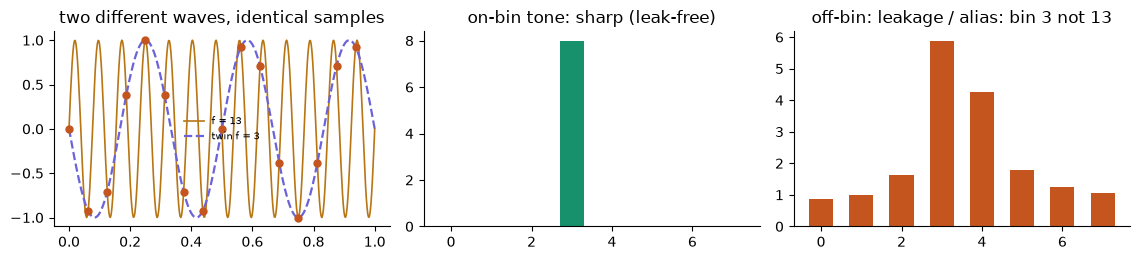

verified: twin identity exact; aliasing relocates the peak, leakage only spreads it


In [4]:
# ============================================================
# Station 3: the twin-wave identity + leakage vs aliasing, all asserted
# [AR] برهان التوأم عدديًا، ثم قياس الفرق بين التسرب (انتشار) والتداخل (موضع خاطئ)
# ============================================================
Ns = 16
ns = np.arange(Ns)

# CLAIM 1 (the twin proof): samples of freq 13 == samples of MINUS freq 3, exactly.
# Reason: 13 = 16 - 3, and e^{2 pi i (16-3) n/16} = e^{-2 pi i 3 n/16} at sample points.
hi = np.sin(TAU * 13 * ns / Ns)
lo = -np.sin(TAU * 3 * ns / Ns)
assert np.allclose(hi, lo)                       # identical digit by digit

# CLAIM 2 (aliasing = wrong position): the DFT of the 13-cycle samples
# puts its low-half peak at bin 3, not 13:
X_alias = dft_euler(hi)
assert np.argmax(np.abs(X_alias[:Ns // 2])) == 3

# CLAIM 3 (leakage = spread, correct position): an on-bin tone is one sharp line;
# an off-bin tone (3.4 cycles) keeps its neighborhood but spreads into neighbors:
on  = np.abs(dft_euler(np.sin(TAU * 3.0 * ns / Ns)))
off = np.abs(dft_euler(np.sin(TAU * 3.4 * ns / Ns)))
assert on[2] < 1e-9 and on[4] < 1e-9            # on-bin: neighbors exactly zero
assert off[2] > 0.5 and off[4] > 0.5            # off-bin: energy leaks to neighbors
assert np.argmax(off[:Ns // 2]) == 3            # ... but the peak stays at the right place

fig, axes = plt.subplots(1, 3, figsize=(11.5, 2.7))
tt = np.linspace(0, 1, 400)
axes[0].plot(tt, np.sin(TAU * 13 * tt), color=PIN, lw=1.2, label="f = 13")
axes[0].plot(tt, -np.sin(TAU * 3 * tt), "--", color=ANGLE, lw=1.6, label="twin f = 3")
axes[0].plot(ns / Ns, hi, "o", color=MIRROR, ms=5)
axes[0].set_title("two different waves, identical samples"); axes[0].legend(fontsize=7, frameon=False)
axes[1].bar(range(Ns // 2), on[:8], color=WAVE, width=0.6);  axes[1].set_title("on-bin tone: sharp (leak-free)")
axes[2].bar(range(Ns // 2), off[:8], color=MIRROR, width=0.6); axes[2].set_title("off-bin: leakage / alias: bin 3 not 13")
for ax in axes:
    for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("verified: twin identity exact; aliasing relocates the peak, leakage only spreads it")

<div dir="rtl">

---
## المحطة الرابعة — الضغط والترشيح: أكبر k مركبات

تجربة «احتفظ بأكبر k مركبات» من محطة التطبيقات، هنا بيدك في numpy: نغمتان وضجيج، ترتيب الحاويات بالطاقة، إعادة البناء من القمم وحدها — والادعاء المقيس: عند k = 3 تبقى ≥ 97٪ من الطاقة ويسقط معظم الضجيج (الملف التفاعلي قاس 98.0٪).

### المهمة 3
جرّب قيمًا مختلفة: ما أصغر k يحفظ 99٪ من الطاقة؟

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 4 — Compression and filtering: the top-k components

The applications station's "keep the top k components" demo, now in your hands in numpy: two tones plus noise, bins ranked by energy, reconstruction from the peaks alone — and the measured claim: at k = 3 at least 97% of the energy survives while most noise falls away (the interactive file measured 98.0%).

### Task 3
Experiment: what is the smallest k that keeps 99% of the energy?

</div>

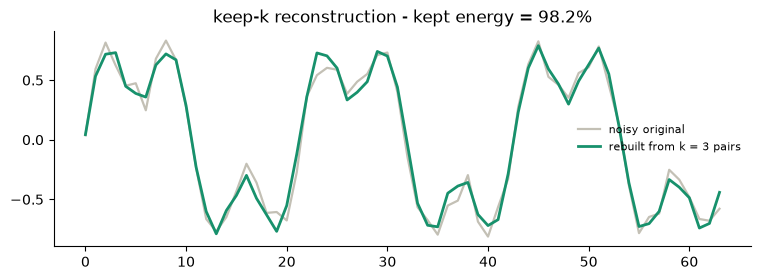

verified: k = 3 keeps 98.2% of the energy - compression and filtering are one move


In [5]:
# ============================================================
# Station 4: rank bins by energy, keep top-k conjugate pairs, reconstruct
# [AR] ترتيب الحاويات بالطاقة والاحتفاظ بأكبر k أزواج وإعادة البناء — مبدأ JPEG/MP3
# ============================================================
noise = (rng.random(Nsig) - 0.5) * 0.30          # seeded noise, same scale as the HTML demo
xs = x + noise                                   # the noisy two-tone signal
X = dft_euler(xs)

def keep_top_k(X, k):
    """Zero all bins except the k highest-energy conjugate PAIRS (bin j with N-j),
    so the reconstruction stays real. Returns (filtered spectrum, kept energy fraction).
    [AR] إبقاء أكبر k أزواج مترافقة فقط كي تبقى إعادة البناء حقيقية"""
    Nl = len(X)
    # pair energy: bin j together with its mirror N-j (DC bin 0 pairs with itself):
    pair_energy = [(j, abs(X[j])**2 + (abs(X[Nl - j])**2 if 0 < j < Nl//2 else 0))
                   for j in range(Nl//2 + 1)]
    pair_energy.sort(key=lambda p: -p[1])        # highest energy first
    keep = set()
    for j, _ in pair_energy[:k]:
        keep.add(j); keep.add((Nl - j) % Nl)     # keep the bin AND its mirror
    Xf = np.array([X[j] if j in keep else 0 for j in range(Nl)])
    kept = sum(e for j, e in pair_energy[:k]) / sum(e for _, e in pair_energy)
    return Xf, kept

def idft(X):
    """Inverse transform (the +i winding direction, divided by N).
    [AR] التحويل العكسي: اللف بالاتجاه المعاكس مقسومًا على N"""
    Nl = len(X); n_ = np.arange(Nl)
    W = np.exp(+2j * pi * np.outer(n_, n_) / Nl)
    return np.real_if_close((W @ X) / Nl)

Xf, kept = keep_top_k(X, 3)
recon = idft(Xf)

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(t, xs, color="#B9B5A8", lw=1.6, alpha=0.85, label="noisy original")
ax.plot(t, recon, color=WAVE, lw=2.0, label="rebuilt from k = 3 pairs")
ax.set_title(f"keep-k reconstruction - kept energy = {kept:.1%}")
ax.legend(frameon=False, fontsize=8)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()

# CLAIM: three pairs carry >= 97% of the energy (tones concentrate, noise scatters):
assert kept >= 0.97
print(f"verified: k = 3 keeps {kept:.1%} of the energy - compression and filtering are one move")

<div dir="rtl">

---
## المحطة الخامسة — القائمة تسكن السعات

الخطوة الأولى إلى الفضاء الكمومي: ثماني عينات تُطبَّع فتصير سعاتِ حالة من ثلاث كيوبتات. نستخدم إشارة جيب التمام النقية بدورتين \([1,0,-1,0,1,0,-1,0]\) — بسعاتها **السالبة** التي لا نظير لها كلاسيكيًا — ونتحقق من شرط الحالة الصحيحة.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 5 — The list moves into the amplitudes

First step into quantum space: eight samples, normalized, become the amplitudes of a three-qubit state. We use the pure two-cycle cosine \([1,0,-1,0,1,0,-1,0]\) — with its **negative** amplitudes, which have no classical counterpart — and verify the valid-state condition.

</div>

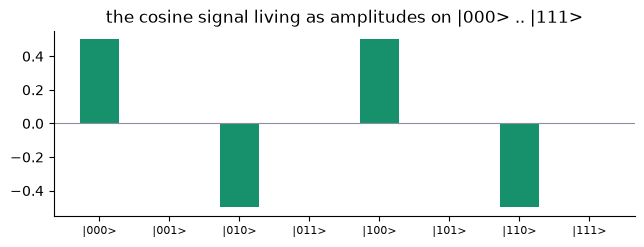

verified: sum|a|^2 = 1 with signed amplitudes [ 0.5  0.  -0.5 -0.   0.5  0.  -0.5 -0. ]


In [6]:
# ============================================================
# Station 5: normalize 8 samples into a valid 3-qubit statevector
# [AR] تطبيع ثماني عينات لتصير سعات حالة صحيحة — مع سعات سالبة مشروعة كموميًا
# ============================================================
Nq = 8                                            # 2^3 states on 3 qubits
sig8 = np.array([np.cos(TAU * 2 * i / Nq) for i in range(Nq)])   # pure frequency 2
amp = sig8 / np.linalg.norm(sig8)                 # normalize: sum of squares -> 1

# CLAIM 1: it is a valid quantum state (probabilities sum to one):
assert abs(np.sum(amp**2) - 1) < 1e-12
# CLAIM 2: negative amplitudes are present - sign is information, invisible to |.|^2:
assert amp.min() < -0.4

fig, ax = plt.subplots(figsize=(7.5, 2.4))
ax.bar(range(Nq), amp, color=WAVE, width=0.55)
ax.axhline(0, color="#8B8FA3", lw=0.8)
ax.set_xticks(range(Nq)); ax.set_xticklabels([f"|{i:03b}>" for i in range(Nq)], fontsize=8)
ax.set_title("the cosine signal living as amplitudes on |000> .. |111>")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()
print(f"verified: sum|a|^2 = 1 with signed amplitudes {np.round(amp, 3)}")

<div dir="rtl">

---
## المحطة السادسة — الحدس قبل الدائرة: قِس قبل التحويل وبعده

القياسُ يعيد موضعًا واحدًا. من الحالة الخام تقع النتائج على المواضع 0 و2 و4 و6 حيث لا تنعدم السعة — والتردد 2 غير مقروء منها. بعد التحويل **لا تقع النتائج إلا على 2 أو 6**: التردد مقروء من قياس واحد. مئتا قياس محاكاة لكل جهة، والادعاءان `assert`:

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 6 — Intuition before the circuit: measure before and after

Measurement returns one position. From the raw state, outcomes land on positions 0, 2, 4, 6 where the amplitude is nonzero — and frequency 2 cannot be read off them. After the transform, **outcomes land only on 2 or 6**: the frequency is readable from a single shot. Two hundred simulated measurements per side, both claims asserted:

</div>

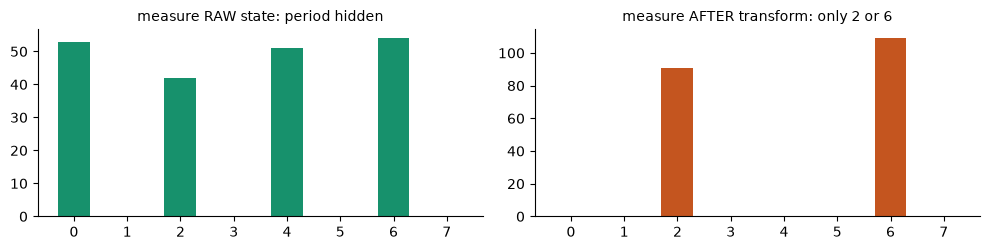

verified: raw shots scatter over {0,2,4,6}; post-transform shots are only {2,6}


In [7]:
# ============================================================
# Station 6: sample measurements from |a|^2, before vs after the transform
# [AR] محاكاة القياس قبل التحويل وبعده: التركز على 2 و6 يجعل التردد مقروءًا
# ============================================================
F8 = np.array([[np.exp(2j*pi*j*k/Nq)/sqrt(Nq) for k in range(Nq)] for j in range(Nq)])
after = F8 @ amp                                   # the transformed state (QFT convention: +i)

p_raw   = amp**2                                   # measurement distribution, raw state
p_after = np.abs(after)**2                         # ... and after the transform

# CLAIM 1 (exact distributions): raw support = {0,2,4,6}; after = {2,6} at 1/2 each:
assert set(np.flatnonzero(p_raw > 1e-12)) == {0, 2, 4, 6}
assert set(np.flatnonzero(p_after > 1e-12)) == {2, 6}
assert np.allclose(p_after[[2, 6]], 0.5)

# simulate 200 shots per side (rng.choice draws indices with the given probabilities):
shots_raw   = rng.choice(Nq, size=200, p=p_raw)
shots_after = rng.choice(Nq, size=200, p=p_after)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.6))
for shots, ttl, ax in ((shots_raw, "measure RAW state: period hidden", axes[0]),
                       (shots_after, "measure AFTER transform: only 2 or 6", axes[1])):
    cnt = np.bincount(shots, minlength=Nq)
    ax.bar(range(Nq), cnt, color=[MIRROR if c and ttl.startswith("measure AFTER") else WAVE for c in cnt], width=0.6)
    ax.set_title(ttl, fontsize=10); ax.set_xticks(range(Nq))
    for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

# CLAIM 2: every post-transform shot is 2 or 6 - frequency read in one measurement:
assert set(shots_after) <= {2, 6}
print("verified: raw shots scatter over {0,2,4,6}; post-transform shots are only {2,6}")

<div dir="rtl">

---
## المحطة السابعة — بوابةً بوابة، ثم المعادلة القابلة للفحص

سبع خطوات من عدة الدورة — هادامارد وأقراص الطور المتناصفة وتبديل — نبنيها خطوةً خطوة ونعرض الحالة بعد كل بوابة (المقدار والطور معًا). ثم **الادعاء المركزي للملفين معًا**: مصفوفة الدائرة كاملةً تساوي مصفوفة DFT (بمعامل \(1/\sqrt{N}\) وإشارة الأس الموجبة) بدقة \(10^{-9}\) — «QFT هو DFT نفسه» جملةً يفحصها `assert`.

### المهمة 4 (ورقية)
أي بوابة تكتب أي خانة من الكسر الثنائي لعامل اللف \(jk/8\)؟ استعن بالمعادلة المفككة في الملف التفاعلي.

<details><summary>الحل | Solution</summary>

كل هادامارد يفتتح كسر كيوبته بخانته الأولى، وكل قرص CP يضيف خانة أدق: \(jk/8 = k_2(0.j_0j_1j_2)+k_1(0.j_1j_2)+k_0(0.j_2)\) — والتبديل يوزع الكسور على خانات k الصحيحة.
Each Hadamard opens its qubit's fraction with the leading digit and each CP disk appends a finer one; the swap routes the fractions to the correct digits of k.
</details>

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 7 — Gate by gate, then the checkable equation

Seven steps from the course toolkit — Hadamards, halving phase disks, one swap — built step by step, displaying magnitude *and phase* after every gate. Then **the central claim of both files**: the full circuit's matrix equals the DFT matrix (with the \(1/\sqrt{N}\) factor and the positive-exponent convention) to \(10^{-9}\) — "QFT *is* the DFT", as a sentence an `assert` can check.

### Task 4 (paper)
Which gate writes which binary-fraction digit of the winding factor \(jk/8\)? Use the decomposed equation from the interactive file.

</div>

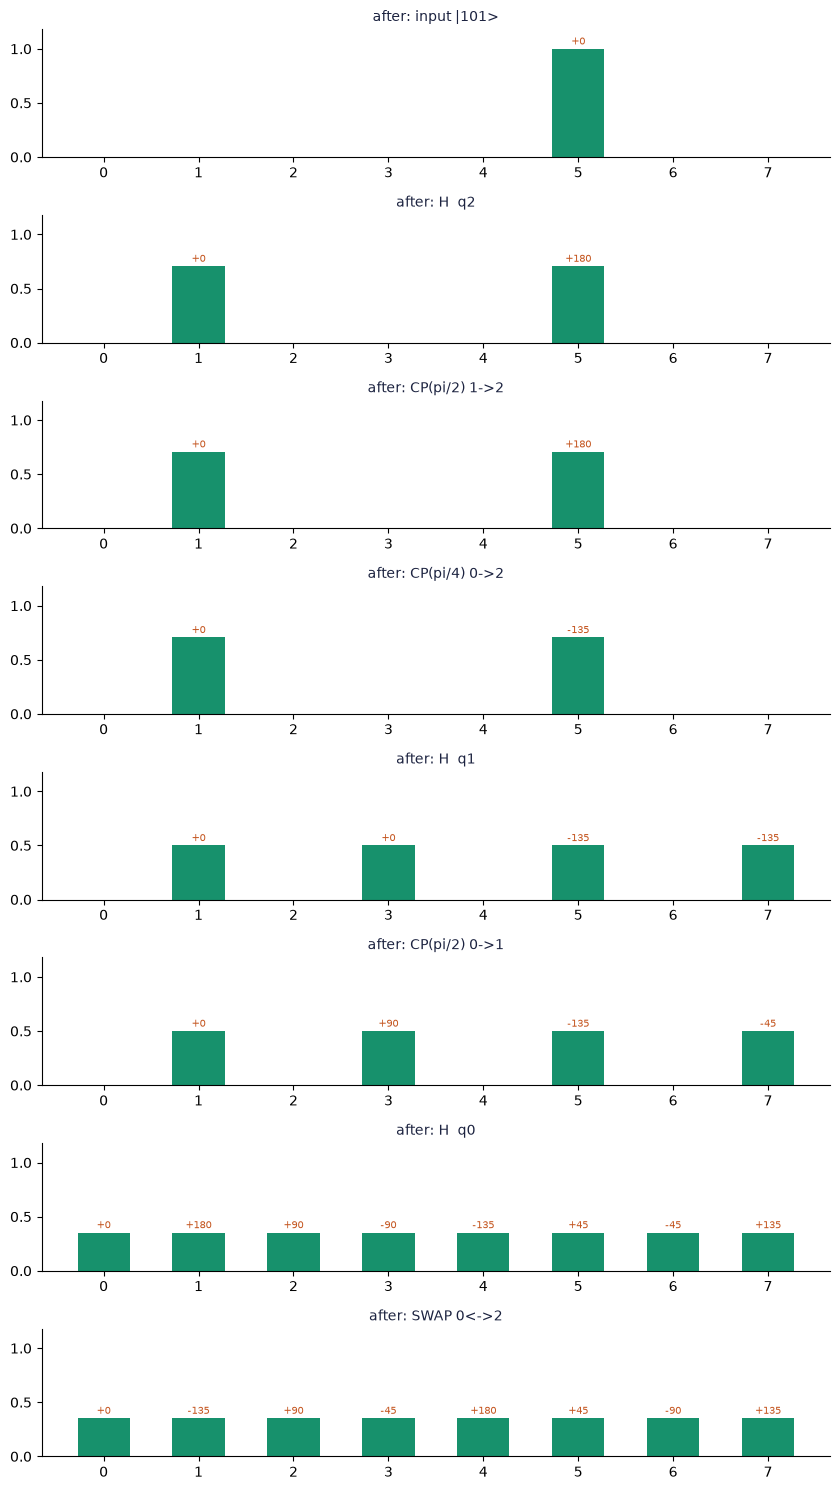

watch the phase disks: 90-degree then 45-degree writes - binary fractions, digit by digit


In [8]:
# ============================================================
# Station 7a: the QFT circuit built gate by gate, state displayed after each
# [AR] بناء دائرة التحويل بوابة بوابة وعرض المقدار والطور بعد كل خطوة للدخل |101>
# ============================================================
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector

j_in = 5                                    # input basis state |101>

# the seven gates, in D02's order (with Qiskit's mirrored qubit labels):
STEPS = [
    ("H  q2",          lambda qc: qc.h(2)),
    ("CP(pi/2) 1->2",  lambda qc: qc.cp(pi/2, 1, 2)),
    ("CP(pi/4) 0->2",  lambda qc: qc.cp(pi/4, 0, 2)),
    ("H  q1",          lambda qc: qc.h(1)),
    ("CP(pi/2) 0->1",  lambda qc: qc.cp(pi/2, 0, 1)),
    ("H  q0",          lambda qc: qc.h(0)),
    ("SWAP 0<->2",     lambda qc: qc.swap(0, 2)),
]

def qft_upto(step, j=j_in, n=3):
    """Circuit preparing |j> then applying the first `step` QFT gates.
    [AR] دائرة تهيئ |j> ثم تطبق أول step بوابة من التحويل"""
    qc = QuantumCircuit(n)
    for q in range(n):                       # prepare |j>: X where bit q of j is 1
        if (j >> q) & 1: qc.x(q)
    for _, g in STEPS[:step]:
        g(qc)
    return qc

def show_qstate(v, title, ax):
    """Magnitude bars with the phase (in degrees) printed on each nonzero bar.
    [AR] أعمدة المقدار مع طباعة الطور بالدرجات فوق كل عمود غير صفري"""
    mags, phs = np.abs(v), np.degrees(np.angle(v))
    ax.bar(range(len(v)), mags, color=WAVE, width=0.55)
    for k2, (mg, ph) in enumerate(zip(mags, phs)):
        if mg > 1e-6:
            ax.text(k2, mg + 0.04, f"{ph:+.0f}", ha="center", fontsize=7, color=MIRROR)
    ax.set_ylim(0, 1.18); ax.set_xticks(range(len(v)))
    ax.set_title(title, fontsize=10, color=INK)
    for s in ("top", "right"): ax.spines[s].set_visible(False)

fig, axes = plt.subplots(8, 1, figsize=(8.5, 15))
for step, ax in enumerate(axes):
    v = Statevector(qft_upto(step)).data            # exact statevector after `step` gates
    lab = "input |101>" if step == 0 else STEPS[step - 1][0]
    show_qstate(v, f"after: {lab}", ax)
plt.tight_layout(); plt.show()
print("watch the phase disks: 90-degree then 45-degree writes - binary fractions, digit by digit")

In [9]:
# ============================================================
# Station 7b: THE matrix equality - Operator(circuit) == DFT matrix, to 1e-9
# [AR] المعادلة القابلة للفحص: مصفوفة الدائرة تساوي مصفوفة DFT حرفيًا
# ============================================================
n3, N3 = 3, 8
qft_full = qft_upto(7, j=0)                         # j=0 -> no X prep, pure QFT gates
# strip nothing: with j=0 the circuit is exactly the 7 QFT gates.

# the DFT matrix in the QUANTUM convention: positive exponent, 1/sqrt(N):
F = np.array([[np.exp(2j*pi*a*b/N3)/sqrt(N3) for b in range(N3)] for a in range(N3)])

U = Operator(qft_full).data

# THE CLAIM of the whole journey - QFT is the DFT matrix, exactly:
assert np.allclose(U, F, atol=1e-9)
print("verified: Operator(7-gate circuit) == DFT matrix (positive exponent, 1/sqrt(N)) to 1e-9")

# and column-wise, for the displayed input: the final state is column j of F:
v5 = Statevector(qft_upto(7)).data
assert np.allclose(v5, F[:, j_in], atol=1e-9)
print(f"verified: the 8 amplitudes after the stepper equal column {j_in} of the DFT matrix -")
print("          equal magnitudes 1/sqrt(8), phases advancing by j*45 degrees per state")

verified: Operator(7-gate circuit) == DFT matrix (positive exponent, 1/sqrt(N)) to 1e-9
verified: the 8 amplitudes after the stepper equal column 5 of the DFT matrix -
          equal magnitudes 1/sqrt(8), phases advancing by j*45 degrees per state


<div dir="rtl">

---
## المحطة الثامنة — المعكوس، ومعاينة إيجاد الدور

المعكوس \(iQFT\) هو الأقراص نفسها تدور عكسًا — نتحقق أنه مرافق المصفوفة تمامًا. ثم معاينة الجسر إلى اليوم الرابع: إشارة دورية بالدور 2، تحويل، قياس، ثم **الكسور المتصلة من ملف الدورة `helpers.py`** تقرأ الدور من النتيجة — خط أنابيب شور مصغّرًا.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 8 — The inverse, and a period-finding preview

The inverse \(iQFT\) is the same disks spinning backward — we verify it equals the matrix adjoint exactly. Then the bridge to Day 4: a period-2 signal, transform, measure, and **continued fractions from the course file `helpers.py`** read the period off the outcome — Shor's pipeline in miniature.

</div>

In [10]:
# ============================================================
# Station 8: iQFT == adjoint; then measure -> continued fractions -> period
# [AR] المعكوس مرافقًا تامًا، ثم خط الأنابيب المصغر: قياس فكسور متصلة فدور
# ============================================================
iqft = qft_upto(7, j=0).inverse()                   # Qiskit inverts gate-by-gate
# CLAIM 1: the inverse circuit's matrix is the exact adjoint (F dagger):
assert np.allclose(Operator(iqft).data, F.conj().T, atol=1e-9)
print("verified: Operator(iqft) == F-dagger - same disks, opposite spin")

# --- the course's continued-fraction tools (from helpers.py; inline fallback kept
#     so the notebook runs standalone if the file is absent):
try:
    from helpers import contFrac, convergents
except ImportError:
    from fractions import Fraction
    def contFrac(x, k=25, tol=1e-9):
        cf = []
        for _ in range(k):
            a = int(x); cf.append(a)
            frac = x - a
            if frac < tol: break
            x = 1.0 / frac
        return cf
    def convergents(cf):
        out = []
        for i in range(len(cf)):
            c = Fraction(cf[i])
            for a in reversed(cf[:i]): c = a + 1 / c
            out.append(c)
        return out

# a period-2 pulse train on 8 positions (the D01-style periodic list):
pulse = np.array([1, 0, 1, 0, 1, 0, 1, 0], dtype=float)
# CLAIM 2: it really is period-2 (shift by 2 leaves it unchanged):
assert np.allclose(pulse, np.roll(pulse, 2))
v_in = pulse / np.linalg.norm(pulse)

p_out = np.abs(F @ v_in) ** 2                       # transform, then measurement dist
# CLAIM 3: outcomes only at multiples of N/r = 4:
assert set(np.flatnonzero(p_out > 1e-12)) == {0, 4}

s_meas = 4                                          # the informative outcome
ratio = s_meas / N3
cands = [c for c in convergents(contFrac(ratio)) if c.denominator > 1]
r = cands[0].denominator
# CLAIM 4: continued fractions hand back the true period:
assert r == 2
print(f"verified: measure s = {s_meas} -> s/N = {ratio} -> convergent 1/{r} -> period r = {r}")
print("this exact pipeline, scaled up, is Day 4: order finding inside Shor's algorithm")

verified: Operator(iqft) == F-dagger - same disks, opposite spin
verified: measure s = 4 -> s/N = 0.5 -> convergent 1/2 -> period r = 2
this exact pipeline, scaled up, is Day 4: order finding inside Shor's algorithm


<div dir="rtl">

---
## ما بعد المتصفح — الرميات، وقانون الكلفة، وفاتورة الترجمة

ثلاثة قياسات لا يقدمها الملف التفاعلي: (1) قياس فعلي بالمحاكي — كل رمية تقع على 2 أو 6 حصرًا؛ (2) **قانون البوابات \(n(n+1)/2\)** مفحوصًا لكل n من 2 إلى 8؛ (3) فاتورة الترجمة إلى بوابات العتاد.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Beyond the browser — shots, the cost law, and the transpilation bill

Three measurements the interactive file cannot make: (1) real simulator shots — every single one lands on 2 or 6; (2) **the gate-count law \(n(n+1)/2\)** checked for every n from 2 to 8; (3) the transpilation bill in hardware gates.

</div>

In [11]:
# ============================================================
# Beyond 1: AerSimulator shots on the cosine state + QFT - outcomes only {2, 6}
# [AR] قياس فعلي: تهيئة حالة جيب التمام ثم التحويل ثم ألفا رمية — كلها على 2 أو 6
# ============================================================
from qiskit import transpile
from qiskit_aer import AerSimulator
sim = AerSimulator()

qc = QuantumCircuit(3)
qc.initialize(amp)                     # load the cosine amplitudes (state prep has a cost!)
qc.compose(qft_upto(7, j=0), inplace=True)
qc.measure_all()

counts = sim.run(transpile(qc, sim), shots=2000, seed_simulator=11).result().get_counts()
outcomes = {int(b, 2): c for b, c in counts.items()}
print("outcome counts:", dict(sorted(outcomes.items())))

# CLAIM: with an exact period-2 cosine, EVERY shot is 2 or 6 (zeros are exact zeros):
assert set(outcomes) <= {2, 6}
assert abs(outcomes.get(2, 0) - 1000) < 120        # ~50/50 split, statistical margin
print("verified: 2000/2000 shots on {2, 6} - the frequency is readable from any single shot")

outcome counts: {2: 1023, 6: 977}
verified: 2000/2000 shots on {2, 6} - the frequency is readable from any single shot


In [12]:
# ============================================================
# Beyond 2 + 3: the n(n+1)/2 law for every n, then the hardware bill
# [AR] قانون العد n(n+1)/2 مفحوصًا لكل حجم، ثم فاتورة الترجمة لبوابات العتاد
# ============================================================
def qft_generic(n):
    """The same construction for any n (H + halving CP disks + swaps).
    [AR] البناء نفسه لأي عدد كيوبتات"""
    qc = QuantumCircuit(n)
    for jq in reversed(range(n)):
        qc.h(jq)
        for kq in reversed(range(jq)):
            qc.cp(pi / 2 ** (jq - kq), kq, jq)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc

# CLAIM 1: H + CP counts equal n(n+1)/2 exactly, for every n from 2 to 8:
for nq in range(2, 9):
    ops = qft_generic(nq).count_ops()
    core = ops.get("h", 0) + ops.get("cp", 0)
    assert core == nq * (nq + 1) // 2, (nq, dict(ops))
print("verified: gate count h + cp == n(n+1)/2 for all n in 2..8 - quadratic, for an exponential-length list")

# CLAIM 2 (the bill): in hardware basis the cost is real but still polynomial:
for nq in (3, 6):
    tq = transpile(qft_generic(nq), basis_gates=["cx", "rz", "sx", "x"], optimization_level=1)
    print(f"n = {nq}: transpiled -> {dict(tq.count_ops())} | depth {tq.depth()}")
tq6 = transpile(qft_generic(6), basis_gates=["cx", "rz", "sx", "x"], optimization_level=1)
assert tq6.count_ops().get("cx", 0) >= 2 * (6 * 5 // 2)   # each CP costs >= 2 cx
print("verified: each abstract CP disk costs two entangling gates on hardware")

verified: gate count h + cp == n(n+1)/2 for all n in 2..8 - quadratic, for an exponential-length list
n = 3: transpiled -> {'rz': 15, 'cx': 9, 'sx': 3} | depth 20
n = 6: transpiled -> {'rz': 57, 'cx': 39, 'sx': 6} | depth 44
verified: each abstract CP disk costs two entangling gates on hardware


<div dir="rtl">

---
## الخاتمة والمهام الإضافية

سلسلة الادعاءات المثبتة آليًا: صيغتا المعادلة عملية واحدة؛ مركز ثقل اللف يقيس النغمات؛ توأم التداخل تطابق حرفي والتسرب انتشار لا انتقال؛ ثلاثة أزواج تحمل 97٪+ من الطاقة؛ القياس بعد التحويل يقرأ التردد من رمية واحدة؛ **مصفوفة الدائرة تساوي مصفوفة DFT بدقة 10⁻⁹**؛ المعكوس مرافق تام؛ الكسور المتصلة تقرأ الدور؛ وقانون \(n(n+1)/2\) صحيح لكل حجم مفحوص.

### مهام للاستزادة
1. **دور مختلف:** بدّل النبضة إلى دور 4. أين تقع القمم؟ وماذا تعيد الكسور المتصلة؟ أثبت بـ`assert`.
2. **اتفاق D02:** أعد بناء `qft_upto` بترتيب دفتر D02 (`qubits[0]` أعلى خانة) وأثبت أن المصفوفة الناتجة هي F بعد تبديل ترتيب البتات.
3. **كسر التسرب:** ولّد نغمة 3.5 دورة وجرب إطالة النافذة إلى 32 عينة — هل يختفي التسرب أم يقل؟ فسّر.

### الروابط
- الملف التفاعلي المرافق: `qsilver-d3-ft-deep-ar.html`
- الدفتر الشقيق: `Extra_Grover_Lab.ipynb` · ملف شور: `qsilver-d4-shor-ar.html`

*QSilver39 — مادة إثرائية · إعداد م. أحمد الغضبان · مصطلحات معجم حوسبة الكم — quantabic.com*

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Closing and extension tasks

The chain of mechanically-proven claims: both equation forms are one operation; the winding center of mass measures tones; the aliasing twin is a literal identity while leakage only spreads; three pairs carry 97%+ of the energy; post-transform measurement reads frequency in one shot; **the circuit matrix equals the DFT matrix to 10⁻⁹**; the inverse is the exact adjoint; continued fractions read the period; and the \(n(n+1)/2\) law holds at every tested size.

### Extension tasks
1. **A different period:** switch the pulse to period 4. Where do the peaks land, and what do continued fractions return? Prove with `assert`.
2. **The D02 convention:** rebuild `qft_upto` in notebook D02's ordering (`qubits[0]` = MSB) and prove the resulting matrix is F with bit-reversed indices.
3. **Break the leakage:** generate a 3.5-cycle tone and lengthen the window to 32 samples — does leakage vanish or shrink? Explain.

*QSilver39 — enrichment material · prepared by Eng. Ahmed Elghadban · terminology per quantabic.com*

</div>